# Checkpoints Inspection (MLM/NSP + Attention Hooks)

학습 중 저장된 체크포인트(`checkpoint_step_*.pth`)를 로드해서,
- `metrics.csv`로 학습 진행 확인
- 입력 문장으로 MLM/NSP 예측 확인
- attention을 hook으로 추출해 heatmap으로 시각화
까지 수행합니다.


In [1]:
import re
import csv
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

REPO_ROOT = Path(".").resolve()
# 노트북 실행 cwd가 repo 루트가 아닐 수 있으므로, 상위로 올라가며 `runs/`를 찾습니다.
while not (REPO_ROOT / "runs").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "runs").exists(), f"Could not locate repo root with `runs/`. cwd={Path('.').resolve()}"
SRC_ROOT = (REPO_ROOT / "src").resolve()
BERT_DIR = (SRC_ROOT / "model").resolve()

import sys
# `src/model`에는 __init__.py가 없을 수 있어서, 패키지 import 대신 파일 폴더를 sys.path에 추가합니다.
if str(BERT_DIR) not in sys.path:
    sys.path.insert(0, str(BERT_DIR))

from bert import BERT, BERTLM
from transformers import BertTokenizerFast

RUN_DIR = REPO_ROOT / "runs" / "L12_H768_A12_seed42_NoNSP"
assert RUN_DIR.exists(), f"RUN_DIR not found: {RUN_DIR}"

CKPT_STEPS = sorted(
    [
        int(m.group(1))
        for p in RUN_DIR.glob("checkpoint_step_*.pth")
        for m in [re.search(r"checkpoint_step_(\\d+)\\.pth$", p.name)]
        if m is not None
    ]
)
CKPT_STEPS


/home/ssai/anaconda3/envs/bert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[]

Loaded 100 metric rows from metrics.csv
Last row: {'step': '1000000', 'epoch': '1', 'lr': '0.0', 'train_loss': '2.129091501235962', 'mlm_loss': '2.129091501235962', 'train_mlm_acc': '0.592901878914405', 'step_time': '0.0776745849289', 'gpu_mem_gb': '2.1146931648254395'}


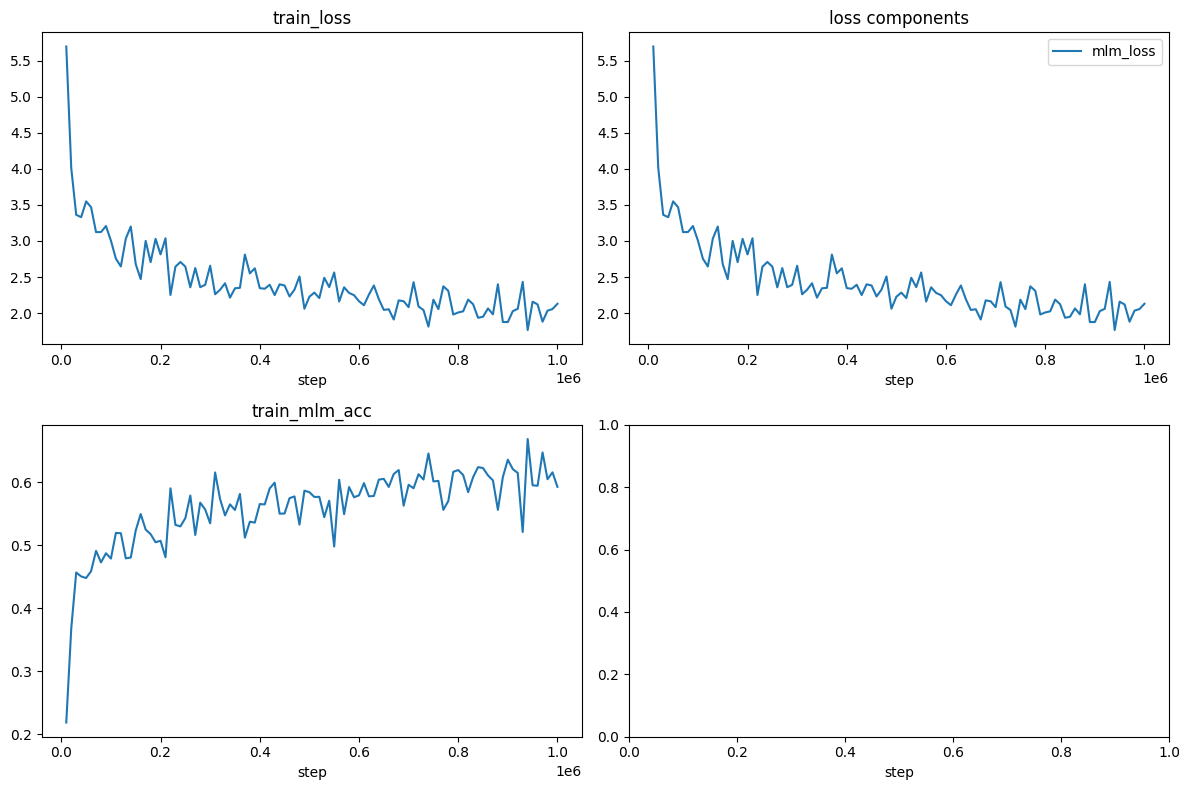

In [4]:
metrics_path = RUN_DIR / "metrics.csv"
assert metrics_path.exists(), f"metrics.csv not found: {metrics_path}"

rows = []
with metrics_path.open("r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for r in reader:
        rows.append(r)

print(f"Loaded {len(rows)} metric rows from {metrics_path.name}")
print("Last row:", rows[-1])

steps = [int(r["step"]) for r in rows]
train_loss = [float(r["train_loss"]) for r in rows]
mlm_loss = [float(r["mlm_loss"]) for r in rows]
train_mlm_acc = [float(r["train_mlm_acc"]) for r in rows]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
axes[0].plot(steps, train_loss)
axes[0].set_title("train_loss")
axes[1].plot(steps, mlm_loss, label="mlm_loss")
axes[1].set_title("loss components")
axes[1].legend()
axes[2].plot(steps, train_mlm_acc)
axes[2].set_title("train_mlm_acc")
for ax in axes:
    ax.set_xlabel("step")
plt.tight_layout()
plt.show()


In [5]:
CKPT_STEP = 1000000  # change if you want (e.g. 100000, 200000, 300000)
# assert CKPT_STEP in CKPT_STEPS, f"CKPT_STEP not found. Available: {CKPT_STEPS}"

ckpt_path = RUN_DIR / f"checkpoint_step_{CKPT_STEP}.pth"
ckpt_path


PosixPath('/home/ssai/Workspace/BERT_repo/runs/L12_H768_A12_seed42_NoNSP/checkpoint_step_1000000.pth')

In [6]:
def get_metrics_for_step(step: int):
    with metrics_path.open("r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            if int(r["step"]) == int(step):
                return r
    return None

print("metrics at checkpoint step:", get_metrics_for_step(CKPT_STEP))

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
if tokenizer.pad_token_id != 0:
    raise ValueError(f"Expected pad_token_id=0, got {tokenizer.pad_token_id}")

vocab_size = tokenizer.vocab_size
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"

model = BERTLM(BERT(vocab_size=vocab_size)).to(device)
model.eval()

ckpt = torch.load(ckpt_path, map_location="cpu")
model.load_state_dict(ckpt["model_state_dict"], strict=True)
print(f"Loaded checkpoint: {ckpt_path.name} on device: {device}")


metrics at checkpoint step: {'step': '1000000', 'epoch': '1', 'lr': '0.0', 'train_loss': '2.129091501235962', 'mlm_loss': '2.129091501235962', 'train_mlm_acc': '0.592901878914405', 'step_time': '0.0776745849289', 'gpu_mem_gb': '2.1146931648254395'}


RuntimeError: Error(s) in loading state_dict for BERTLM:
	Missing key(s) in state_dict: "next_sentence.dense.weight", "next_sentence.dense.bias", "next_sentence.classifier.weight", "next_sentence.classifier.bias". 

## NSP sanity check (라벨/구현 이상 탐지)

- A: 랜덤 초기화 모델에서 `true nsp_label`의 loss가 `~ln(2)=0.693` 근처인지 확인
- B: 학습 모델에서 `nsp_label`을 셔플하면 loss가 유의미하게 올라가는지 확인

이 두 조건이 동시에 맞으면, 현재 `nsp_loss`가 낮아 보이는 현상이 상대적으로 신뢰할만합니다.

In [7]:
from datasets import load_from_disk

DATASET_DIR = REPO_ROOT / "data" / "pretraining_instances_spmask"
assert DATASET_DIR.exists(), f"dataset dir not found: {DATASET_DIR}"

# 작은 샘플로 sanity check만 수행합니다.
N = 32
ds = load_from_disk(str(DATASET_DIR))
N = min(N, len(ds))
batch = ds.select(range(N))

input_ids = torch.tensor(batch["input_ids"], dtype=torch.long)
token_type_ids = torch.tensor(batch["token_type_ids"], dtype=torch.long)
nsp_labels_true = torch.tensor(batch["nsp_label"], dtype=torch.long)

input_ids = input_ids.to(device)
token_type_ids = token_type_ids.to(device)
nsp_labels_true = nsp_labels_true.to(device)

# Same shuffle order for both models
perm = torch.randperm(N)
nsp_labels_shuf = nsp_labels_true[perm]

criterion_nsp = torch.nn.CrossEntropyLoss()

# (B) 학습 모델: true label vs shuffled label
pred_nsp_logits, _ = model(input_ids, token_type_ids)
loss_nsp_true = float(criterion_nsp(pred_nsp_logits, nsp_labels_true).item())
loss_nsp_shuf = float(criterion_nsp(pred_nsp_logits, nsp_labels_shuf).item())

# (A) 랜덤 초기화 모델: true label에서의 loss (기대값 ~ 0.693)
model_rand = BERTLM(BERT(vocab_size=vocab_size))
model_rand = model_rand.to(device)
model_rand.eval()

pred_nsp_logits_rand, _ = model_rand(input_ids, token_type_ids)
loss_rand_true = float(criterion_nsp(pred_nsp_logits_rand, nsp_labels_true).item())
loss_rand_shuf = float(criterion_nsp(pred_nsp_logits_rand, nsp_labels_shuf).item())

print(f"[Trained] NSP loss (true labels):      {loss_nsp_true:.4f}")
print(f"[Trained] NSP loss (shuffled labels):  {loss_nsp_shuf:.4f}")
print(f"[Random ] NSP loss (true labels):      {loss_rand_true:.4f}  (expect ~0.693)")
print(f"[Random ] NSP loss (shuffled labels):  {loss_rand_shuf:.4f}")

# Heuristic: shuffled loss가 true loss보다 유의미하게 커지면 라벨/로깅이 정상일 가능성이 큼
print("Heuristic: shuffled_loss - true_loss (trained)=", loss_nsp_shuf - loss_nsp_true)


[Trained] NSP loss (true labels):      0.6929
[Trained] NSP loss (shuffled labels):  0.6995
[Random ] NSP loss (true labels):      0.7546  (expect ~0.693)
[Random ] NSP loss (shuffled labels):  0.7403
Heuristic: shuffled_loss - true_loss (trained)= 0.00656282901763916


In [6]:
@torch.no_grad()
def tokenize_pair(sent_a: str, sent_b: str, max_length: int = 64):
    tok = tokenizer(
        sent_a,
        sent_b,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    return tok["input_ids"], tok["token_type_ids"], tok["attention_mask"]


@torch.no_grad()
def predict_nsp(sent_a: str, sent_b: str, max_length: int = 64):
    input_ids, token_type_ids, attention_mask = tokenize_pair(sent_a, sent_b, max_length=max_length)
    input_ids = input_ids.to(device)
    token_type_ids = token_type_ids.to(device)

    pred_nsp_logits, _ = model(input_ids, token_type_ids)
    probs = F.softmax(pred_nsp_logits, dim=-1)[0].detach().cpu().tolist()
    # Dataset convention: class 0=is_next, class 1=not_next
    return {
        "probs_is_next": probs[0],
        "probs_not_next": probs[1],
        "logits": pred_nsp_logits[0].detach().cpu().tolist(),
        "attention_mask": attention_mask[0].detach().cpu(),
        "input_ids": input_ids[0].detach().cpu(),
    }


@torch.no_grad()
def pick_mask_position(text: str, max_length: int = 64):
    tok = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    input_ids = tok["input_ids"][0]

    pad_id = tokenizer.pad_token_id
    special_mask = torch.tensor(
        tokenizer.get_special_tokens_mask(input_ids.tolist(), already_has_special_tokens=True),
        dtype=torch.bool,
    )

    candidates = torch.where((~special_mask) & (input_ids != pad_id))[0]
    if len(candidates) == 0:
        raise RuntimeError("No valid token positions to mask.")

    # Strategy: mask the first non-special token.
    return tok, int(candidates[0].item())


@torch.no_grad()
def predict_mlm(text: str, max_length: int = 64, topk: int = 10):
    tok, pos = pick_mask_position(text, max_length=max_length)
    input_ids = tok["input_ids"].to(device)
    token_type_ids = tok["token_type_ids"].to(device)

    masked_input_ids = input_ids.clone()
    original_id = int(masked_input_ids[0, pos].item())
    masked_input_ids[0, pos] = tokenizer.mask_token_id

    _, pred_mlm_logits = model(masked_input_ids, token_type_ids)
    logits = pred_mlm_logits[0, pos]  # [vocab]

    topv, topi = torch.topk(logits, k=topk, dim=-1)
    top_tokens = [tokenizer.convert_ids_to_tokens(int(i)) for i in topi.tolist()]
    top_scores = [float(v) for v in topv.tolist()]

    return {
        "masked_position": pos,
        "original_token": tokenizer.convert_ids_to_tokens(original_id),
        "top_tokens": top_tokens,
        "top_scores": top_scores,
    }


def register_attention_hooks(model_: torch.nn.Module):
    """Capture p_attn from each transformer layer's Attention module.

    Each layer's Attention.forward returns (context, p_attn).
    """
    attn_maps = {}  # layer_idx -> [batch, heads, seq, seq] on CPU
    handles = []

    for layer_idx, block in enumerate(model_.bert.encoder_blocks):
        attn_module = block.attention.attention

        def make_hook(li: int):
            def hook(module, inputs, output):
                if isinstance(output, tuple) and len(output) == 2:
                    attn_maps[li] = output[1].detach().cpu()
            return hook

        handles.append(attn_module.register_forward_hook(make_hook(layer_idx)))

    return attn_maps, handles


@torch.no_grad()
def attention_matrix_from_nsp(sent_a: str, sent_b: str, max_length: int = 64, layer: int = 11, head: int = 0):
    input_ids, token_type_ids, attention_mask = tokenize_pair(sent_a, sent_b, max_length=max_length)
    input_ids = input_ids.to(device)
    token_type_ids = token_type_ids.to(device)

    attn_maps, handles = register_attention_hooks(model)
    try:
        model(input_ids, token_type_ids)
    finally:
        for h in handles:
            h.remove()

    if layer not in attn_maps:
        raise RuntimeError(f"No attention map captured for layer={layer}")

    p_attn = attn_maps[layer][0, head]  # [seq, seq]
    seq_len = int(attention_mask[0].sum().item())
    p_attn = p_attn[:seq_len, :seq_len]

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0, :seq_len].detach().cpu().tolist())
    return p_attn.numpy(), tokens


아래에서 예시 문장쌍으로 NSP 확률, 단일 문장으로 MLM top-k를 확인합니다.

In [7]:
examples = [
    ("the man went to the store", "he bought some milk"),
    ("the man went to the store", "the sky is blue"),
]

for a, b in examples:
    res = predict_nsp(a, b, max_length=64)
    print("---")
    print("A:", a)
    print("B:", b)
    print("probs_is_next:", res["probs_is_next"])
    print("probs_not_next:", res["probs_not_next"])

mlm_texts = [
    "the man went to the store and bought some milk",
    "the sky is blue and the sun is bright",
]

for t in mlm_texts:
    mlm_res = predict_mlm(t, max_length=64, topk=8)
    print("---")
    print("Text:", t)
    print("Masked position:", mlm_res["masked_position"])
    print("Original token:", mlm_res["original_token"])
    print("Top tokens:", mlm_res["top_tokens"])
    print("Top scores:", [round(x, 3) for x in mlm_res["top_scores"]])


---
A: the man went to the store
B: he bought some milk
probs_is_next: 0.34652528166770935
probs_not_next: 0.653474748134613
---
A: the man went to the store
B: the sky is blue
probs_is_next: 0.3565971255302429
probs_not_next: 0.6434028744697571
---
Text: the man went to the store and bought some milk
Masked position: 1
Original token: the
Top tokens: ['##bana', 'enrolled', '##ram', 'ma', 'tara', 'romance', 'reed', '##hman']
Top scores: [2.014, 1.979, 1.925, 1.916, 1.873, 1.869, 1.849, 1.844]
---
Text: the sky is blue and the sun is bright
Masked position: 1
Original token: the
Top tokens: ['enrolled', '##bana', 'ma', '##ram', 'continued', 'nature', 'wing', 'stratford']
Top scores: [2.132, 2.096, 2.044, 1.941, 1.888, 1.876, 1.845, 1.792]


In [11]:
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
from transformers import BertTokenizerFast

# repo root 자동 탐색
REPO_ROOT = Path('.').resolve()
while not (REPO_ROOT / 'runs').exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'runs').exists(), f"runs/를 찾지 못했습니다. cwd={Path('.').resolve()}"

SRC_ROOT = REPO_ROOT / 'src'
BERT_DIR = SRC_ROOT / 'model'
if str(BERT_DIR) not in sys.path:
    sys.path.insert(0, str(BERT_DIR))

from bert import BERT, BERTLM_NoNSP

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

RUN_DIR = REPO_ROOT / 'runs' / 'L12_H768_A12_seed42_NoNSP'
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
if tokenizer.pad_token_id != 0:
    raise ValueError(f"Expected pad_token_id=0, got {tokenizer.pad_token_id}")


def load_model(ckpt_path):
    vocab_size = tokenizer.vocab_size
    model = BERTLM_NoNSP(BERT(vocab_size=vocab_size))
    ckpt = torch.load(ckpt_path, map_location='cpu')
    model.load_state_dict(ckpt['model_state_dict'], strict=True)
    model.to(DEVICE)
    model.eval()
    return model


def predict_mlm(model, text, topk=8, max_length=64):
    tok = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt',
    )
    input_ids = tok['input_ids'].to(DEVICE)
    token_type_ids = tok.get('token_type_ids')
    if token_type_ids is None:
        token_type_ids = torch.zeros_like(input_ids)
    token_type_ids = token_type_ids.to(DEVICE)

    mask_positions = (input_ids[0] == tokenizer.mask_token_id).nonzero(as_tuple=False).view(-1)
    assert len(mask_positions) > 0, "[MASK] 토큰이 필요합니다"

    with torch.no_grad():
        mlm_logits = model(input_ids, token_type_ids)

    results = []
    for pos in mask_positions.tolist():
        logits = mlm_logits[0, pos]
        topk_ids = logits.topk(topk).indices.tolist()
        topk_tokens = [tokenizer.convert_ids_to_tokens(i) for i in topk_ids]
        topk_scores = [float(x) for x in logits[topk_ids].tolist()]
        results.append((topk_tokens, topk_scores))
    return results


mlm_texts = [
    'the man went to the [MASK] to buy food',
    'he drank a cup of [MASK]',
    'paris is the capital of [MASK]',
    'the cat sat on the [MASK]',
    'he [MASK] to school yesterday',
]


def evaluate_checkpoint(ckpt_path):
    print(f"\n================ {ckpt_path.name} ================\n")
    model = load_model(ckpt_path)

    print('MLM TEST')
    for text in mlm_texts:
        res = predict_mlm(model, text)
        print('\nText:', text)
        for tokens, scores in res:
            print('Top tokens:', tokens)
            print('Top scores:', [round(s, 3) for s in scores])


checkpoints = [
    RUN_DIR / 'checkpoint_step_1000000.pth',
]

for ckpt in checkpoints:
    if ckpt.exists():
        evaluate_checkpoint(ckpt)
    else:
        print(f'[skip] not found: {ckpt}')



================ checkpoint_step_1000000.pth ================

MLM TEST


ValueError: not enough values to unpack (expected 2, got 1)

In [12]:
import sys
from pathlib import Path
import torch
import torch.nn.functional as F

# 현재 cwd가 repo root가 아닐 수도 있으니 runs/가 있는 상위 디렉토리를 찾습니다.
REPO_ROOT = Path('.').resolve()
while not (REPO_ROOT / 'runs').exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

SRC_ROOT = REPO_ROOT / 'src'
BERT_DIR = SRC_ROOT / 'model'
if str(BERT_DIR) not in sys.path:
    sys.path.insert(0, str(BERT_DIR))

from bert import BERT, BERTLM  # src/model/bert.py
from transformers import BertTokenizerFast

RUN_DIR = REPO_ROOT / 'runs' / 'L12_H768_A12_seed42'

# 사용자가 원하는 체크포인트 스텝을 고르세요.
CKPT_STEP = 400000
ckpt_path = RUN_DIR / f'checkpoint_step_{CKPT_STEP}.pth'
assert ckpt_path.exists(), f'checkpoint not found: {ckpt_path}'

# device 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
if tokenizer.pad_token_id != 0:
    raise ValueError(f"Expected tokenizer.pad_token_id=0, got {tokenizer.pad_token_id}")

vocab_size = tokenizer.vocab_size

# model
model = BERTLM(BERT(vocab_size=vocab_size))
ckpt = torch.load(ckpt_path, map_location='cpu')
model.load_state_dict(ckpt['model_state_dict'], strict=True)
model.to(device)
model.eval()


@torch.no_grad()
def predict_mlm_one_mask(text_with_mask: str, max_length: int = 64, topk: int = 8):
    """입력 text에 '[MASK]'가 포함되어 있다고 가정하고, 해당 마스크 위치 top-k를 반환합니다."""

    tok = tokenizer(
        text_with_mask,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt',
    )
    input_ids = tok['input_ids'].to(device)
    token_type_ids = tok.get('token_type_ids')
    if token_type_ids is None:
        token_type_ids = torch.zeros_like(input_ids)
    token_type_ids = token_type_ids.to(device)

    mask_positions = (input_ids[0] == tokenizer.mask_token_id).nonzero(as_tuple=False).view(-1)
    if len(mask_positions) == 0:
        raise ValueError("입력에 '[MASK]'가 포함되어 있어야 합니다.")

    # 여러 개면 첫 번째만
    pos = int(mask_positions[0].item())

    _, pred_mlm_logits = model(input_ids, token_type_ids)
    logits = pred_mlm_logits[0, pos]  # [vocab]

    topv, topi = torch.topk(logits, k=topk, dim=-1)
    top_tokens = [tokenizer.convert_ids_to_tokens(int(i)) for i in topi.tolist()]
    top_scores = [float(v) for v in topv.tolist()]

    # 가시화용: 토큰 시퀀스(패딩 제외)
    attn_mask = tok.get('attention_mask')
    if attn_mask is None:
        seq_len = (input_ids[0] != 0).sum().item()
    else:
        seq_len = int(attn_mask[0].sum().item())

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0, :seq_len].detach().cpu().tolist())

    return {
        'pos': pos,
        'tokens': tokens,
        'top_tokens': top_tokens,
        'top_scores': top_scores,
    }


@torch.no_grad()
def predict_nsp(sent_a: str, sent_b: str, max_length: int = 64):
    tok = tokenizer(
        sent_a,
        sent_b,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt',
    )
    input_ids = tok['input_ids'].to(device)
    token_type_ids = tok.get('token_type_ids')
    if token_type_ids is None:
        token_type_ids = torch.zeros_like(input_ids)
    token_type_ids = token_type_ids.to(device)

    pred_nsp_logits, _ = model(input_ids, token_type_ids)
    probs = F.softmax(pred_nsp_logits, dim=-1)[0].detach().cpu().tolist()
    # dataset convention: class 0 = is_next, class 1 = not_next
    return {
        'probs_is_next': float(probs[0]),
        'probs_not_next': float(probs[1]),
        'logits': [float(x) for x in pred_nsp_logits[0].detach().cpu().tolist()],
    }


print(f"Loaded checkpoint: {ckpt_path.name} | device={device}")

# =========================
# Quick tests
# =========================
mlm_texts = [
    "the man went to the [MASK] to buy food",
    "he drank a cup of [MASK]",
    "paris is the capital of [MASK]",
]

nsp_examples = [
    ("the man went to the store", "he bought some milk"),
    ("the man went to the store", "quantum physics is difficult"),
]

print("\n🔥 MLM TEST")
for t in mlm_texts:
    res = predict_mlm_one_mask(t, max_length=64, topk=8)
    print("- Text:", t)
    print("  mask_pos:", res['pos'])
    print("  Top tokens:", res['top_tokens'])
    print("  Top scores:", [round(x, 4) for x in res['top_scores']])

print("\n🔥 NSP TEST")
for a, b in nsp_examples:
    res = predict_nsp(a, b, max_length=64)
    print("- A:", a)
    print("  B:", b)
    print("  is_next:", round(res['probs_is_next'], 4), "not_next:", round(res['probs_not_next'], 4))


Loaded checkpoint: checkpoint_step_400000.pth | device=cuda

🔥 MLM TEST
- Text: the man went to the [MASK] to buy food
  mask_pos: 6
  Top tokens: ['kitchen', 'house', 'hospital', 'garden', 'village', 'hotel', 'bank', 'farm']
  Top scores: [8.9645, 8.169, 7.9778, 7.789, 7.7743, 7.6477, 7.5431, 7.3504]
- Text: he drank a cup of [MASK]
  mask_pos: 6
  Top tokens: ['.', 'wine', 'water', '!', 'coffee', 'tea', 'milk', 'pepper']
  Top scores: [13.1722, 9.3302, 8.8537, 8.4717, 8.2799, 7.9906, 7.6804, 7.6286]
- Text: paris is the capital of [MASK]
  mask_pos: 6
  Top tokens: ['.', 'geography', 'references', ';', 'and', 'geometridae', 'of', '!']
  Top scores: [18.8554, 9.1388, 8.3579, 7.8, 7.2686, 6.9122, 6.5809, 6.5753]

🔥 NSP TEST
- A: the man went to the store
  B: he bought some milk
  is_next: 0.9927 not_next: 0.0073
- A: the man went to the store
  B: quantum physics is difficult
  is_next: 0.0085 not_next: 0.9915


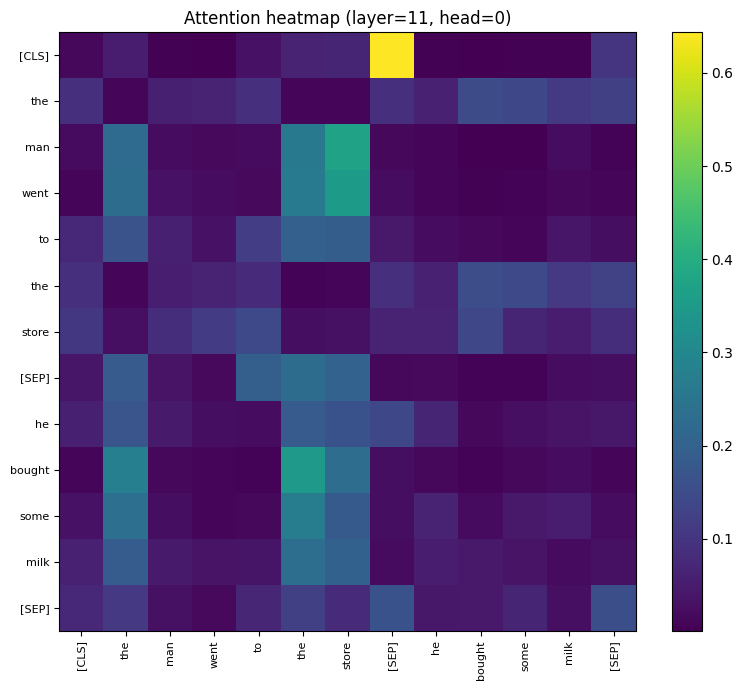

In [13]:
# Attention heatmap (NSP forward)
sent_a, sent_b = examples[0]

layer = 11  # 0..11
head = 0    # 0..11

attn_mat, tokens = attention_matrix_from_nsp(sent_a, sent_b, max_length=64, layer=layer, head=head)

plt.figure(figsize=(8, 7))
plt.imshow(attn_mat, aspect="auto", cmap="viridis")
plt.colorbar()
plt.title(f"Attention heatmap (layer={layer}, head={head})")

# Label only a subset to keep it readable
show_every = max(1, len(tokens) // 20)
tick_positions = list(range(0, len(tokens), show_every))
tick_labels = [tokens[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=8)
plt.yticks(tick_positions, tick_labels, fontsize=8)

plt.tight_layout()
plt.show()
